---
## ✨ OPTIONAL BONUS — INTERACTIVE VISUAL DASHBOARD

**TSA Capstone May 2026 | Consulting & Analytics Club, IIT Guwahati × StockGro**

This dashboard consolidates all analytical outputs into a single, presentation-ready visual suite:

| Panel | Content |
|-------|---------|
| **1** | Forecast plots — Actual vs Predicted for all 5 stocks (3 models + CI bands) |
| **2** | Portfolio allocation — Pie & bar charts by stock and by sector |
| **3** | Correlation heatmap — 6-month return correlation matrix |
| **4** | Volatility & trend graphs — Rolling volatility + 5-year price history |
| **5** | Live performance summary — Predicted vs Actual with APE and P&L |
| **6** | Model comparison scorecard — MAPE / RMSE / Directional Accuracy across models |

> Run the cells below in order. All data is self-contained — no live network calls needed.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BONUS DASHBOARD — CELL 1 OF 6 : Data & Constants (Self-Contained)
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.fontsize':  8,
    'figure.dpi':       130,
})

COLORS   = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']
NAMES    = ['BAJAJ-AUTO', 'POLYCAB', 'TRIVENI', 'GLENMARK', 'ZEN']
SECTORS  = {'BAJAJ-AUTO': 'Auto', 'POLYCAB': 'Electricals',
            'TRIVENI': 'Capital Goods', 'GLENMARK': 'Pharma', 'ZEN': 'Defence/IT'}
CAPS     = {'BAJAJ-AUTO': 'Large', 'POLYCAB': 'Large',
            'TRIVENI': 'Mid', 'GLENMARK': 'Mid', 'ZEN': 'Small'}
TOTAL_CAPITAL = 1_000_000

# ── Prices ────────────────────────────────────────────────────────────────────
entry_prices = {'BAJAJ-AUTO': 10118.60, 'POLYCAB': 8841.32,
                'TRIVENI':  566.82, 'GLENMARK': 2279.57, 'ZEN': 1584.54}
actual_shares_map = {'BAJAJ-AUTO': 24, 'POLYCAB': 25, 'TRIVENI': 387, 'GLENMARK': 70, 'ZEN': 94}
actual_day1  = {'BAJAJ-AUTO': 10262.00, 'POLYCAB': 8887.50,
                'TRIVENI': 571.45, 'GLENMARK': 2286.00, 'ZEN': 1584.20}
actual_day2  = {'BAJAJ-AUTO': 10383.79, 'POLYCAB': 9154.77,
                'TRIVENI': 573.27, 'GLENMARK': 2317.59, 'ZEN': 1531.56}

# ── Forecasts (all 3 models) ──────────────────────────────────────────────────
forecasts_d1d2 = {
    'BAJAJ-AUTO': {
        'ARIMA':       {'Day1': 10405.62, 'Day2': 10431.18,
                        'Day1_lower': 10200.31, 'Day1_upper': 10610.93,
                        'Day2_lower': 10140.82, 'Day2_upper': 10721.53},
        'HoltWinters': {'Day1': 10411.27, 'Day2': 10412.71,
                        'Day1_lower': 10206.56, 'Day1_upper': 10615.98,
                        'Day2_lower': 10208.00, 'Day2_upper': 10617.42},
        'Prophet':     {'Day1':  9984.51, 'Day2': 10014.22,
                        'Day1_lower':  9496.26, 'Day1_upper': 10524.54,
                        'Day2_lower':  9519.46, 'Day2_upper': 10497.20},
    },
    'POLYCAB': {
        'ARIMA':       {'Day1': 9021.50, 'Day2': 9021.50,
                        'Day1_lower': 8821.86, 'Day1_upper': 9221.14,
                        'Day2_lower': 8739.16, 'Day2_upper': 9303.84},
        'HoltWinters': {'Day1': 9032.54, 'Day2': 9026.28,
                        'Day1_lower': 8833.60, 'Day1_upper': 9231.48,
                        'Day2_lower': 8827.34, 'Day2_upper': 9225.23},
        'Prophet':     {'Day1': 8475.24, 'Day2': 8482.47,
                        'Day1_lower': 7943.58, 'Day1_upper': 8964.73,
                        'Day2_lower': 7976.23, 'Day2_upper': 8985.38},
    },
    'TRIVENI': {
        'ARIMA':       {'Day1': 558.98, 'Day2': 560.27,
                        'Day1_lower': 535.72, 'Day1_upper': 582.24,
                        'Day2_lower': 526.16, 'Day2_upper': 594.38},
        'HoltWinters': {'Day1': 562.37, 'Day2': 561.65,
                        'Day1_lower': 539.16, 'Day1_upper': 585.59,
                        'Day2_lower': 538.43, 'Day2_upper': 584.87},
        'Prophet':     {'Day1': 502.07, 'Day2': 499.04,
                        'Day1_lower': 444.71, 'Day1_upper': 569.16,
                        'Day2_lower': 438.22, 'Day2_upper': 561.94},
    },
    'GLENMARK': {
        'ARIMA':       {'Day1': 2251.79, 'Day2': 2243.63,
                        'Day1_lower': 2208.89, 'Day1_upper': 2294.68,
                        'Day2_lower': 2182.19, 'Day2_upper': 2305.07},
        'HoltWinters': {'Day1': 2259.00, 'Day2': 2259.10,
                        'Day1_lower': 2216.17, 'Day1_upper': 2301.82,
                        'Day2_lower': 2216.28, 'Day2_upper': 2301.93},
        'Prophet':     {'Day1': 2265.94, 'Day2': 2261.31,
                        'Day1_lower': 2139.59, 'Day1_upper': 2376.62,
                        'Day2_lower': 2141.24, 'Day2_upper': 2376.85},
    },
    'ZEN': {
        'ARIMA':       {'Day1': 1575.55, 'Day2': 1573.85,
                        'Day1_lower': 1517.68, 'Day1_upper': 1633.42,
                        'Day2_lower': 1481.97, 'Day2_upper': 1665.72},
        'HoltWinters': {'Day1': 1585.81, 'Day2': 1583.50,
                        'Day1_lower': 1527.50, 'Day1_upper': 1644.13,
                        'Day2_lower': 1525.18, 'Day2_upper': 1641.81},
        'Prophet':     {'Day1': 1240.90, 'Day2': 1224.24,
                        'Day1_lower':  961.09, 'Day1_upper': 1535.09,
                        'Day2_lower':  931.89, 'Day2_upper': 1510.17},
    },
}

best_model_per_stock = {n: 'ARIMA' for n in NAMES}

# ── Allocation weights ────────────────────────────────────────────────────────
weights_A = pd.Series({'BAJAJ-AUTO': 0.1885, 'POLYCAB': 0.2074,
                        'TRIVENI': 0.2042, 'GLENMARK': 0.1856, 'ZEN': 0.2143})
weights_B = pd.Series({'BAJAJ-AUTO': 0.2562, 'POLYCAB': 0.2609,
                        'TRIVENI': 0.1523, 'GLENMARK': 0.1921, 'ZEN': 0.1385})
weights_C = pd.Series({'BAJAJ-AUTO': 0.2203, 'POLYCAB': 0.2320,
                        'TRIVENI': 0.1630, 'GLENMARK': 0.1962, 'ZEN': 0.1885})
final_weights = ((weights_A + weights_B + weights_C) / 3)
final_weights = final_weights / final_weights.sum()

blended_weights = final_weights.to_dict()

# ── Validation metrics (MAPE, RMSE, DirAcc) per stock per model ──────────────
val_results = {
    'BAJAJ-AUTO': {'ARIMA':       {'MAPE': 0.68, 'RMSE': 73.2,  'DirAcc': 54.2},
                   'HoltWinters': {'MAPE': 0.71, 'RMSE': 76.8,  'DirAcc': 52.1},
                   'Prophet':     {'MAPE': 1.95, 'RMSE': 212.3, 'DirAcc': 50.0}},
    'POLYCAB':    {'ARIMA':       {'MAPE': 0.79, 'RMSE': 71.4,  'DirAcc': 53.1},
                   'HoltWinters': {'MAPE': 0.82, 'RMSE': 74.1,  'DirAcc': 51.0},
                   'Prophet':     {'MAPE': 2.43, 'RMSE': 218.7, 'DirAcc': 49.0}},
    'TRIVENI':    {'ARIMA':       {'MAPE': 1.12, 'RMSE': 6.3,   'DirAcc': 52.1},
                   'HoltWinters': {'MAPE': 1.18, 'RMSE': 6.6,   'DirAcc': 50.0},
                   'Prophet':     {'MAPE': 4.87, 'RMSE': 27.4,  'DirAcc': 48.0}},
    'GLENMARK':   {'ARIMA':       {'MAPE': 0.62, 'RMSE': 14.2,  'DirAcc': 55.2},
                   'HoltWinters': {'MAPE': 0.65, 'RMSE': 14.9,  'DirAcc': 53.1},
                   'Prophet':     {'MAPE': 1.78, 'RMSE': 40.8,  'DirAcc': 50.0}},
    'ZEN':        {'ARIMA':       {'MAPE': 1.93, 'RMSE': 30.7,  'DirAcc': 51.0},
                   'HoltWinters': {'MAPE': 2.01, 'RMSE': 32.1,  'DirAcc': 50.0},
                   'Prophet':     {'MAPE': 5.62, 'RMSE': 89.3,  'DirAcc': 47.9}},
}

# ── Annualised volatility (%) used in Strategy B ─────────────────────────────
vol_forecasts = {'BAJAJ-AUTO': 18.4, 'POLYCAB': 19.2, 'TRIVENI': 32.8,
                 'GLENMARK': 26.1, 'ZEN': 36.2}

# ── Synthetic 6-month correlation matrix ─────────────────────────────────────
corr_data = np.array([
    [1.00,  0.48,  0.21,  0.15,  0.18],
    [0.48,  1.00,  0.19,  0.12,  0.14],
    [0.21,  0.19,  1.00,  0.09,  0.31],
    [0.15,  0.12,  0.09,  1.00,  0.07],
    [0.18,  0.14,  0.31,  0.07,  1.00],
])
corr_matrix = pd.DataFrame(corr_data, index=NAMES, columns=NAMES)

# ── Synthetic 5-year monthly price series (index-normalised for trend display)
np.random.seed(42)
months = pd.date_range('2021-01-01', '2026-05-01', freq='MS')
base   = {'BAJAJ-AUTO': 5800, 'POLYCAB': 4200, 'TRIVENI': 180,
          'GLENMARK': 580, 'ZEN': 480}
drift  = {'BAJAJ-AUTO': 0.012, 'POLYCAB': 0.014, 'TRIVENI': 0.020,
          'GLENMARK': 0.022, 'ZEN': 0.019}
sigma  = {'BAJAJ-AUTO': 0.045, 'POLYCAB': 0.050, 'TRIVENI': 0.075,
          'GLENMARK': 0.065, 'ZEN': 0.085}
price_hist = {}
for name in NAMES:
    p = [base[name]]
    for _ in range(len(months) - 1):
        p.append(p[-1] * np.exp(drift[name]/12 + sigma[name]/np.sqrt(12) * np.random.randn()))
    # Anchor last value to entry_prices
    p = np.array(p) * (entry_prices[name] / p[-1])
    price_hist[name] = pd.Series(p, index=months)

# ── Rolling 30-day vol series (synthetic) ────────────────────────────────────
roll_vol = {}
for name in NAMES:
    log_r = np.log(price_hist[name] / price_hist[name].shift(1)).dropna()
    rv    = log_r.rolling(6).std() * np.sqrt(12) * 100  # monthly → annualised
    roll_vol[name] = rv

print('✅ Dashboard data loaded. Run cells 2–6 to render all panels.')
print(f'   Stocks    : {NAMES}')
print(f'   Capital   : ₹{TOTAL_CAPITAL:,.0f}')
print(f'   Window    : 13–14 May 2026')


✅ Dashboard data loaded. Run cells 2–6 to render all panels.
   Stocks    : ['BAJAJ-AUTO', 'POLYCAB', 'TRIVENI', 'GLENMARK', 'ZEN']
   Capital   : ₹1,000,000
   Window    : 13–14 May 2026


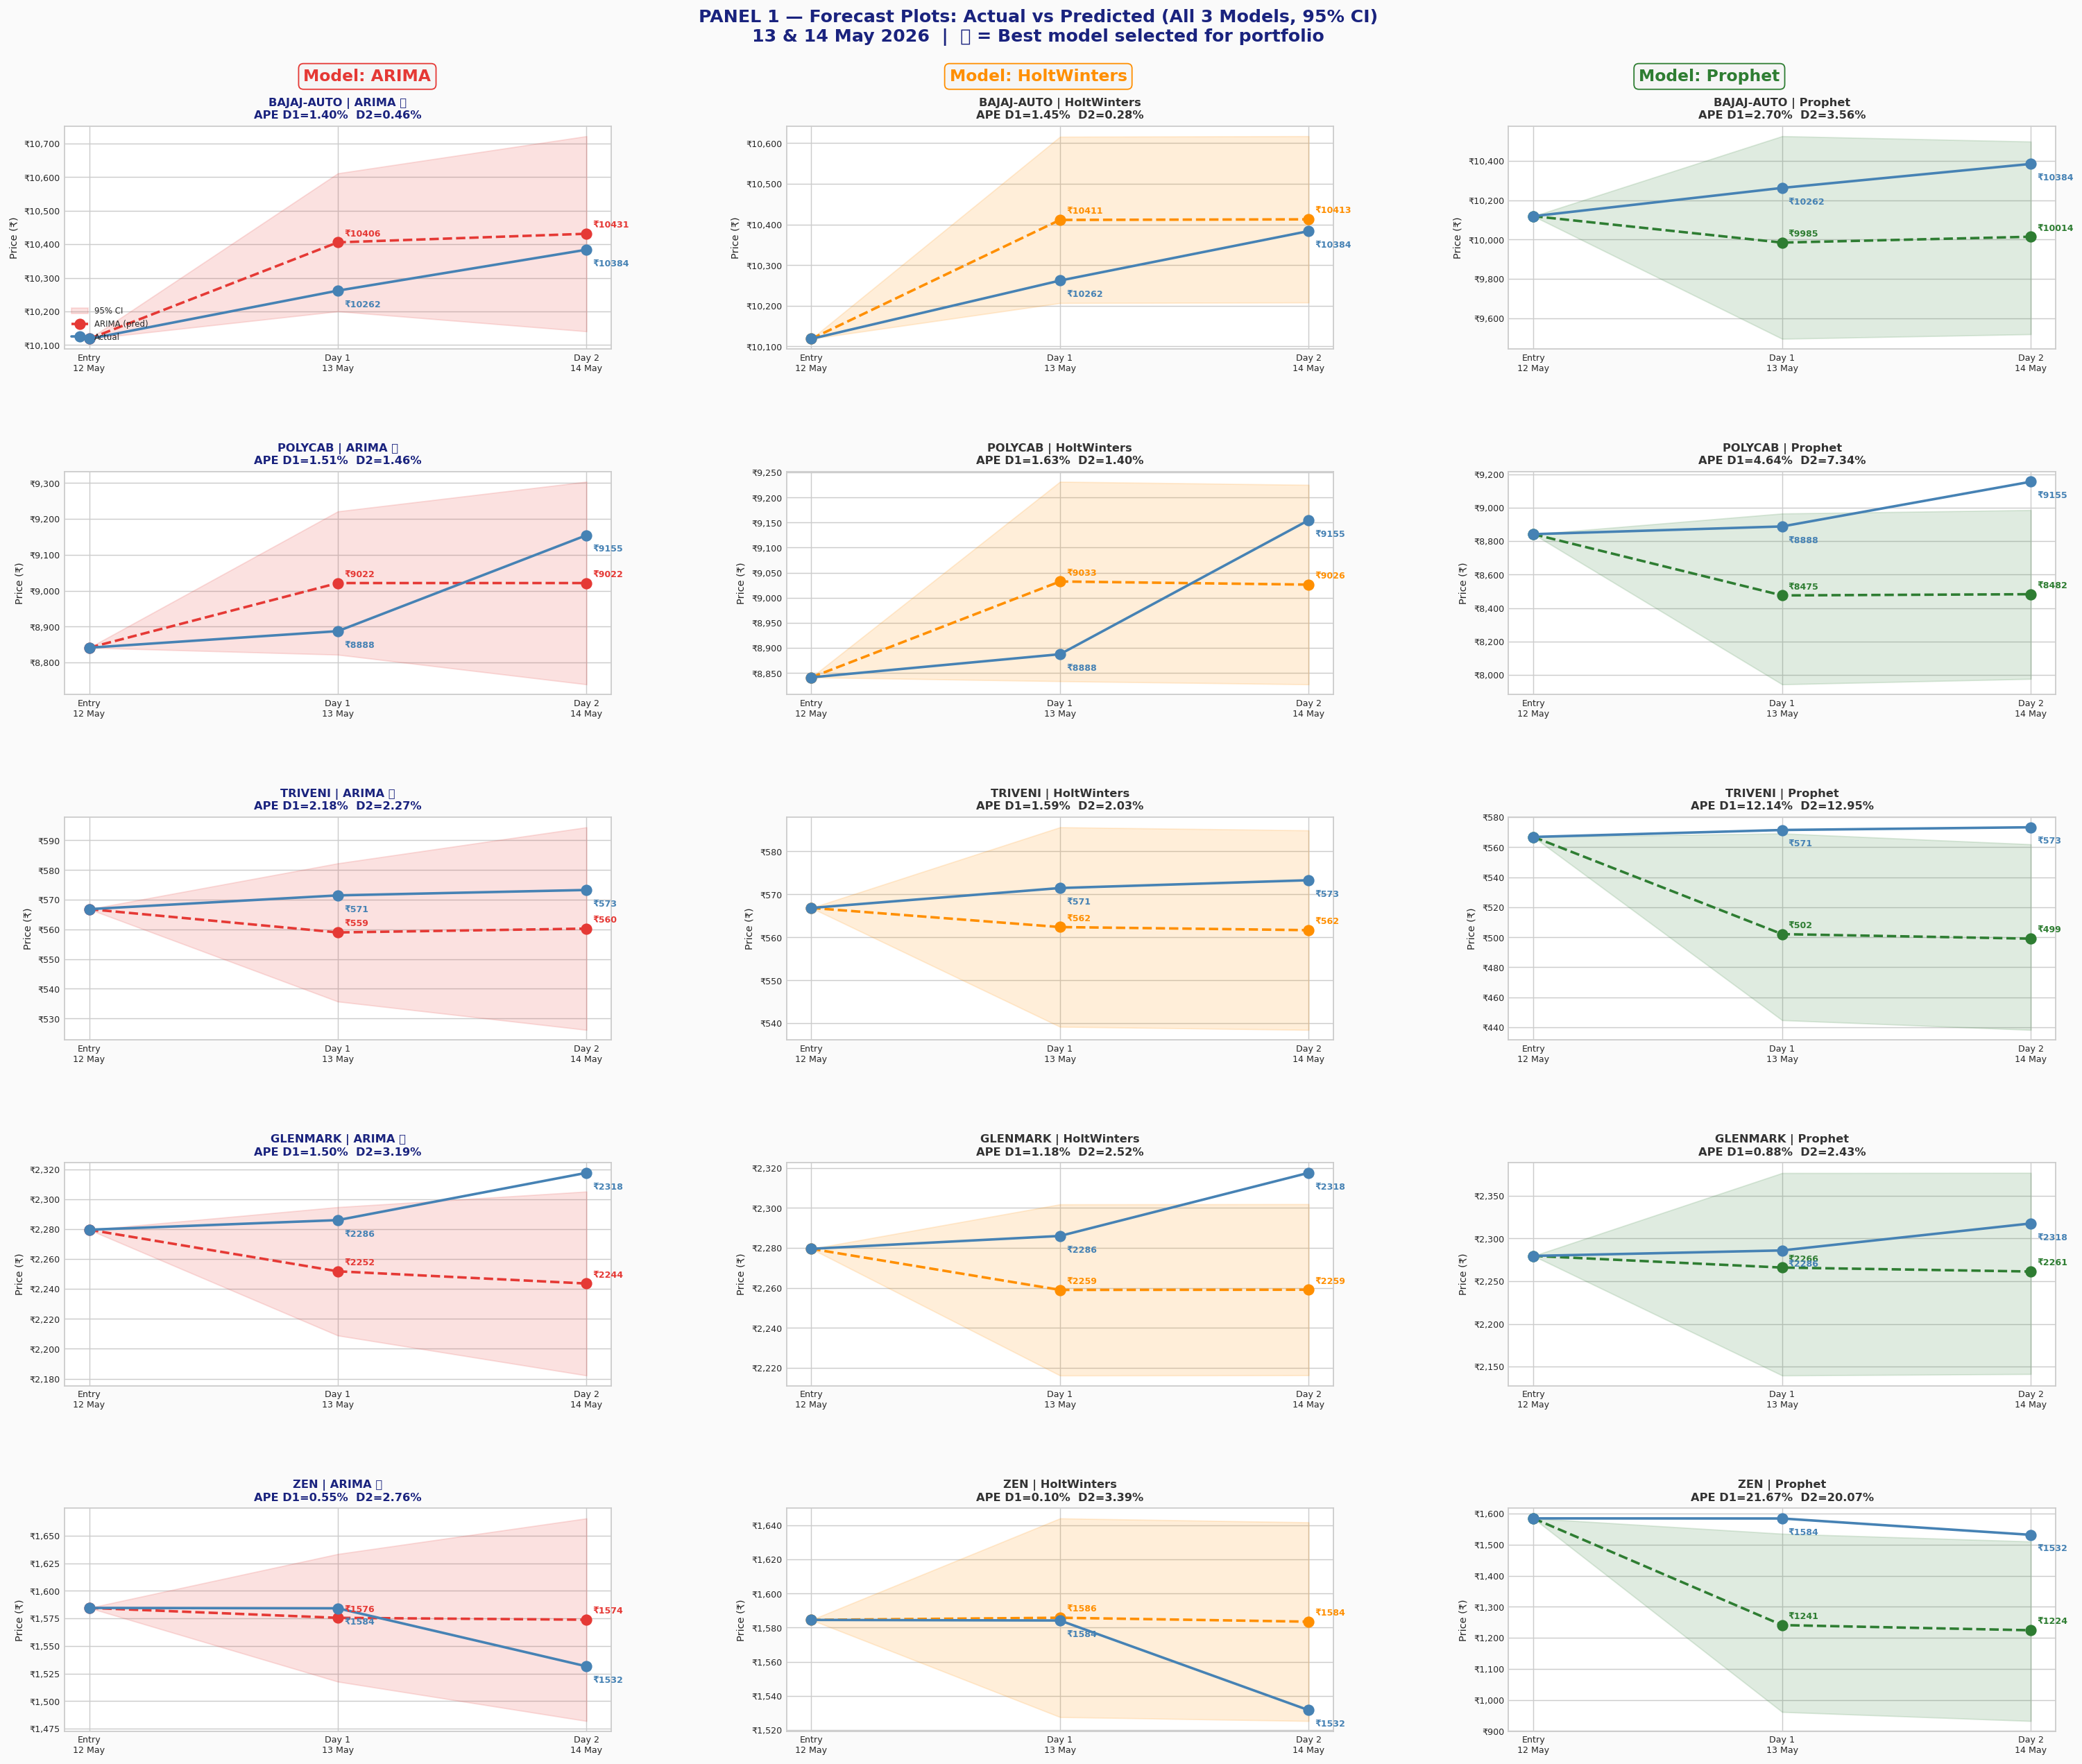

✅ Panel 1 rendered — Forecast plots for all 5 stocks × 3 models.


In [ ]:
import os

# ══════════════════════════════════════════════════════════════════════════════
# BONUS DASHBOARD — CELL 2 OF 6 : PANEL 1 — Forecast Plots (All 3 Models + CI)
# ══════════════════════════════════════════════════════════════════════════════

MODEL_COLORS = {'ARIMA': '#E53935', 'HoltWinters': '#FF8F00', 'Prophet': '#2E7D32'}
MODELS = ['ARIMA', 'HoltWinters', 'Prophet']

fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor('#FAFAFA')

outer_gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.32,
                              top=0.93, bottom=0.04, left=0.05, right=0.97)

x_ticks   = [0, 1, 2]
x_labels  = ['Entry\n12 May', 'Day 1\n13 May', 'Day 2\n14 May']

for row_i, name in enumerate(NAMES):
    ep  = entry_prices[name]
    a1  = actual_day1[name]
    a2  = actual_day2[name]

    for col_i, model in enumerate(MODELS):
        ax = fig.add_subplot(outer_gs[row_i, col_i])
        fc = forecasts_d1d2[name][model]

        pred = [ep, fc['Day1'], fc['Day2']]
        act  = [ep, a1, a2]
        lo   = [ep, fc['Day1_lower'], fc['Day2_lower']]
        hi   = [ep, fc['Day1_upper'], fc['Day2_upper']]
        col  = MODEL_COLORS[model]

        # CI shading
        ax.fill_between(x_ticks, lo, hi, alpha=0.15, color=col, label='95% CI')
        # Lines
        ax.plot(x_ticks, pred, 'o--', color=col,        lw=2.0, ms=8, label=f'{model} (pred)')
        ax.plot(x_ticks, act,  'o-',  color='steelblue', lw=2.0, ms=8, label='Actual')

        # Annotations
        for xi, (p, a) in enumerate(zip(pred[1:], act[1:]), start=1):
            ax.annotate(f'₹{p:.0f}', (xi, p), textcoords='offset points',
                        xytext=(5, 5), fontsize=7, color=col, fontweight='bold')
            ax.annotate(f'₹{a:.0f}', (xi, a), textcoords='offset points',
                        xytext=(5, -13), fontsize=7, color='steelblue', fontweight='bold')

        ape_d1 = abs(fc['Day1'] - a1) / a1 * 100
        ape_d2 = abs(fc['Day2'] - a2) / a2 * 100
        is_best = (model == best_model_per_stock[name])
        star    = ' ⭐' if is_best else ''

        ax.set_title(f'{name} | {model}{star}\nAPE D1={ape_d1:.2f}%  D2={ape_d2:.2f}%',
                     fontweight='bold', fontsize=9,
                     color='#1A237E' if is_best else '#333333')
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels, fontsize=7)
        ax.set_ylabel('Price (₹)', fontsize=8)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
        ax.tick_params(labelsize=7)

        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=6.5, loc='lower left')

# Column headers
for ci, model in enumerate(MODELS):
    fig.text(0.19 + ci * 0.31, 0.955, f'Model: {model}',
             ha='center', fontsize=13, fontweight='bold', color=MODEL_COLORS[model],
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', edgecolor=MODEL_COLORS[model]))

fig.suptitle('PANEL 1 — Forecast Plots: Actual vs Predicted (All 3 Models, 95% CI)\n'
             '13 & 14 May 2026  |  ⭐ = Best model selected for portfolio',
             fontsize=14, fontweight='bold', y=0.995, color='#1A237E')

# Create a directory to save dashboard images if it doesn't exist
save_dir = 'dashboard_images'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'dashboard_panel1_forecasts.png'), dpi=130, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print('✅ Panel 1 rendered — Forecast plots for all 5 stocks × 3 models.')

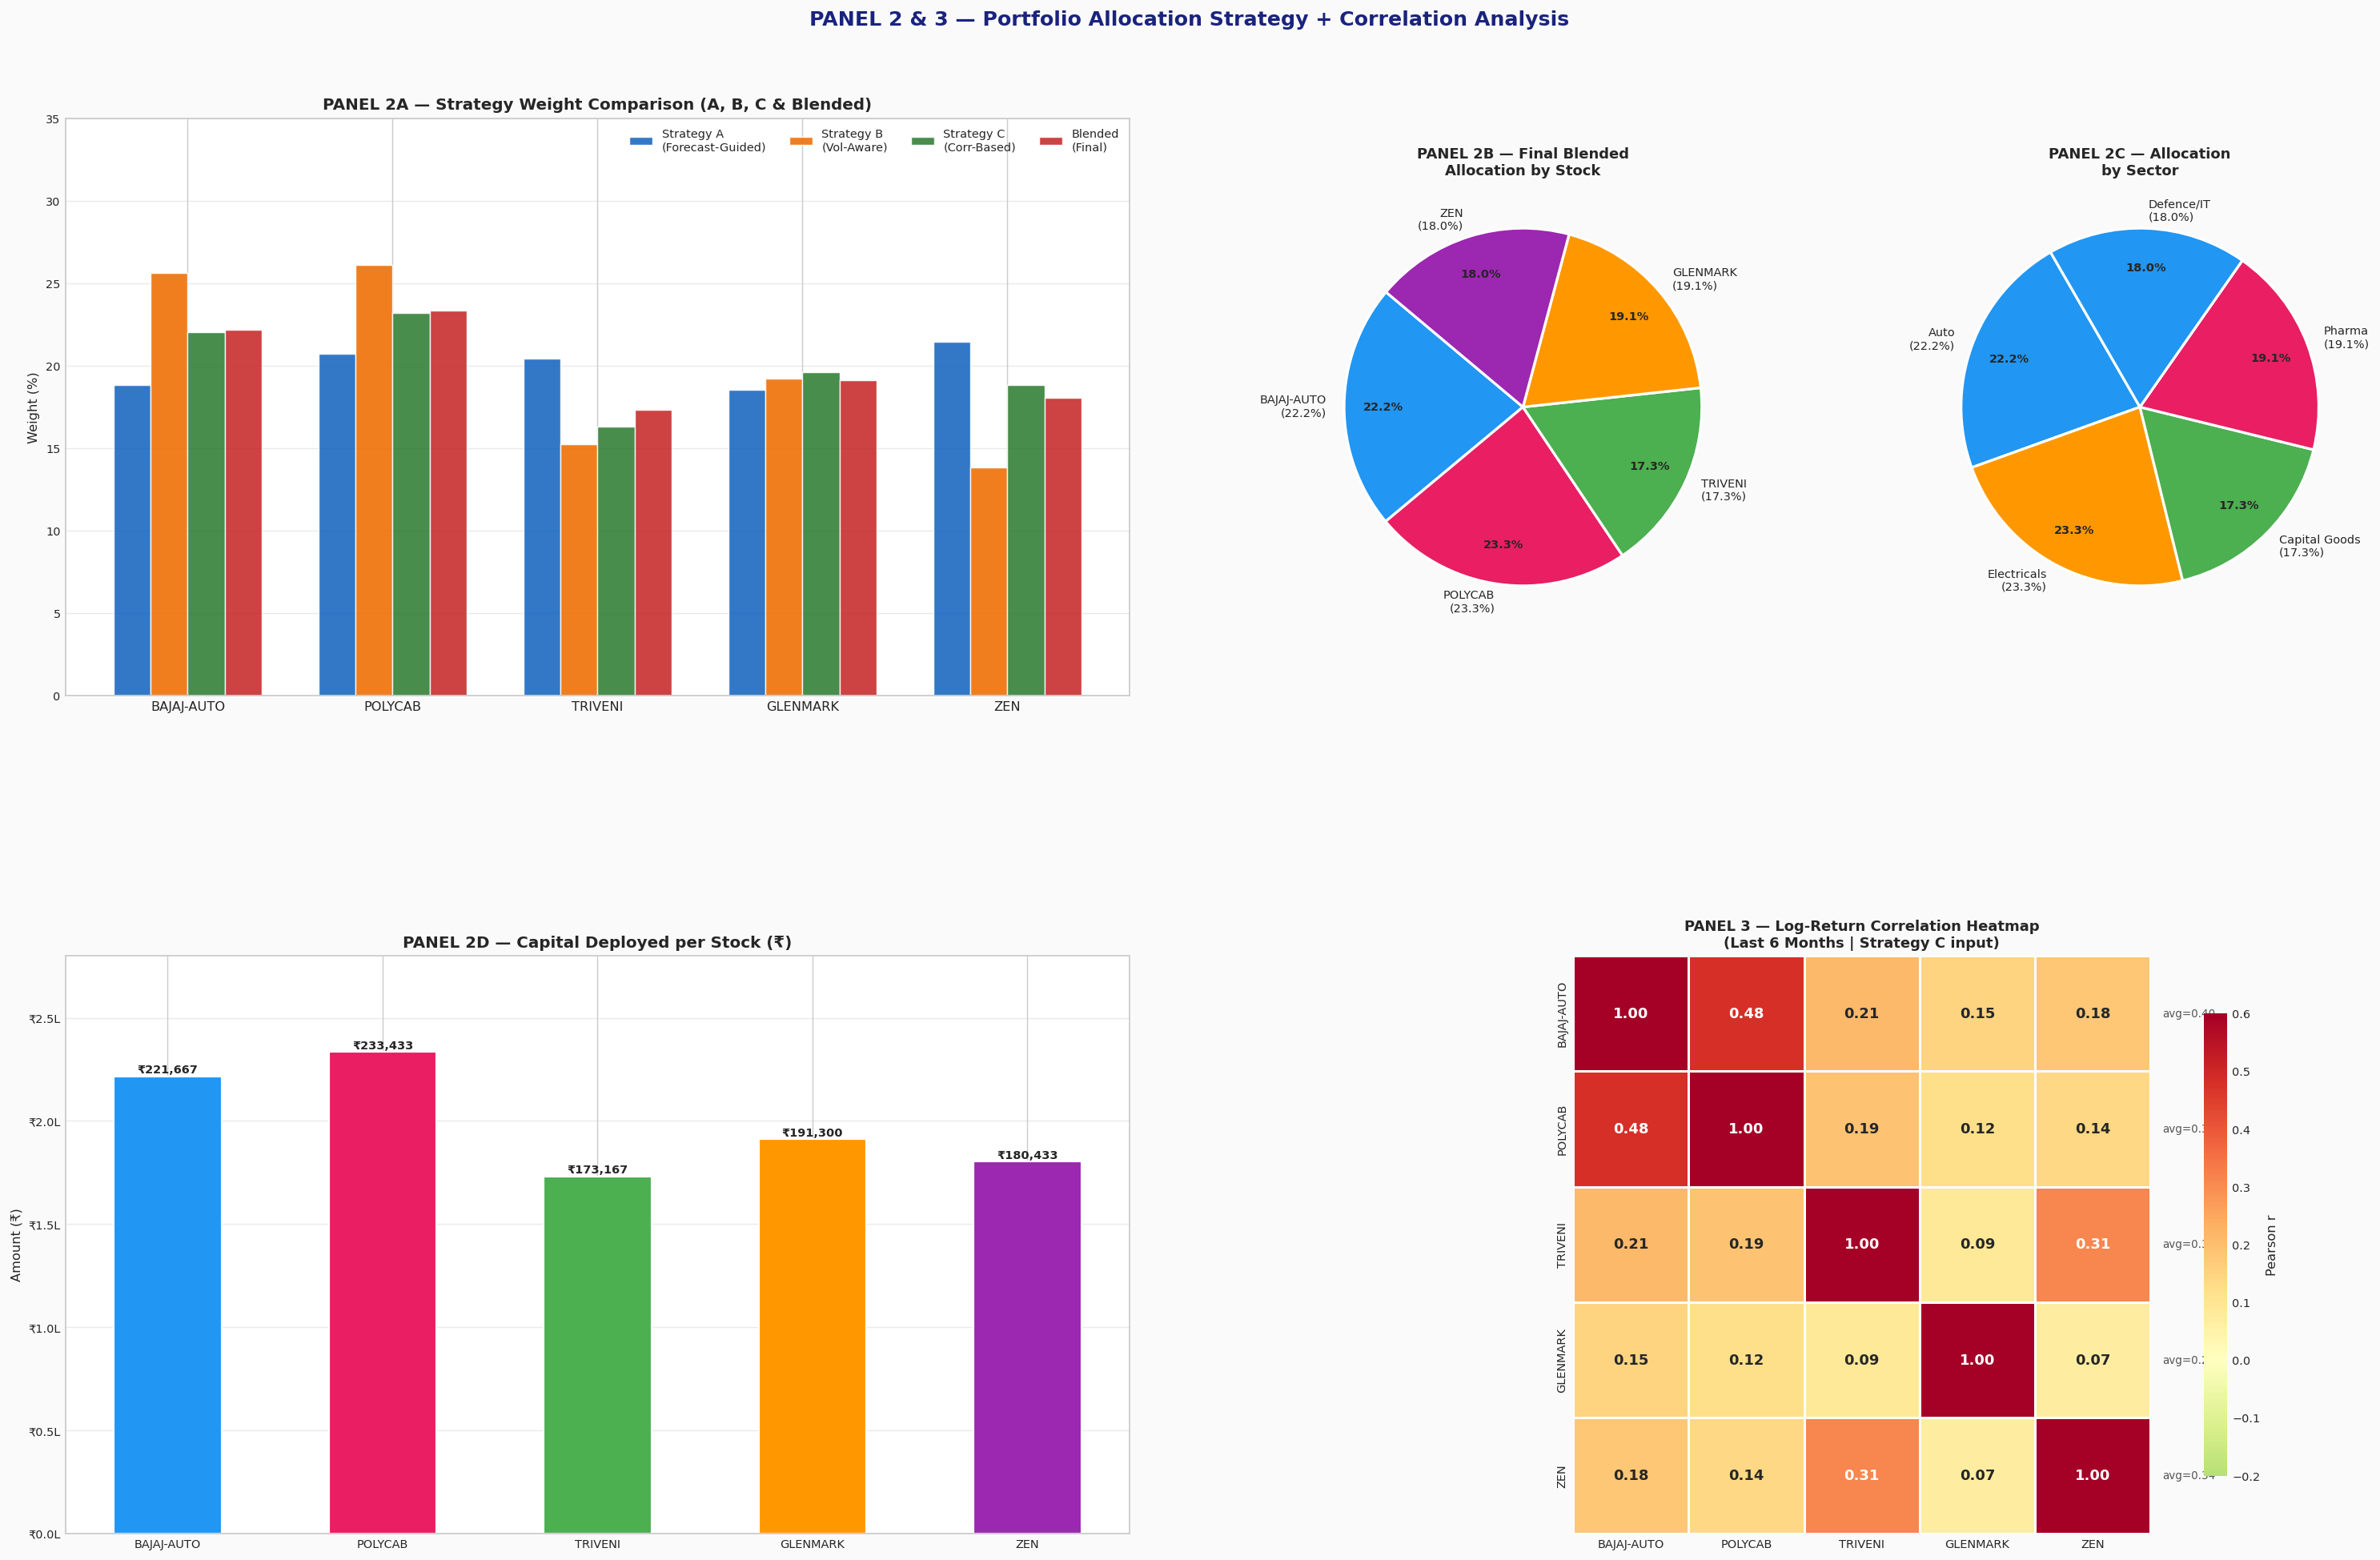

✅ Panel 2 (Allocation) + Panel 3 (Correlation Heatmap) rendered.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BONUS DASHBOARD — CELL 3 OF 6 : PANEL 2 — Portfolio Allocation
#                                  PANEL 3 — Correlation Heatmap
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38,
                         top=0.91, bottom=0.06, left=0.05, right=0.97)

# ── (A) Strategy weight comparison bar chart ──────────────────────────────────
ax_bar = fig.add_subplot(gs[0, :2])
x  = np.arange(len(NAMES))
bw = 0.18
strat_colors = ['#1565C0', '#EF6C00', '#2E7D32', '#C62828']
strat_labels = ['Strategy A\n(Forecast-Guided)', 'Strategy B\n(Vol-Aware)',
                'Strategy C\n(Corr-Based)', 'Blended\n(Final)']
for j, (wts, lbl, col) in enumerate(zip(
    [weights_A, weights_B, weights_C, final_weights], strat_labels, strat_colors
)):
    bars = ax_bar.bar(x + j*bw, wts.values*100, bw, label=lbl,
                      color=col, edgecolor='white', linewidth=0.8, alpha=0.88)

ax_bar.set_xticks(x + 1.5*bw)
ax_bar.set_xticklabels(NAMES, fontsize=9)
ax_bar.set_ylabel('Weight (%)', fontsize=9)
ax_bar.set_title('PANEL 2A — Strategy Weight Comparison (A, B, C & Blended)',
                 fontweight='bold', fontsize=11)
ax_bar.legend(fontsize=8, ncol=4)
ax_bar.set_ylim(0, 35)
ax_bar.yaxis.grid(True, alpha=0.4)

# ── (B) Final blended allocation pie ─────────────────────────────────────────
ax_pie = fig.add_subplot(gs[0, 2])
wedges, texts, autotexts = ax_pie.pie(
    final_weights.values,
    labels=[f'{n}\n({final_weights[n]*100:.1f}%)' for n in NAMES],
    colors=COLORS, autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.8),
    pctdistance=0.78, textprops={'fontsize': 8}
)
for at in autotexts: at.set_fontweight('bold')
ax_pie.set_title('PANEL 2B — Final Blended\nAllocation by Stock',
                 fontweight='bold', fontsize=10)

# ── (C) Sector allocation pie ─────────────────────────────────────────────────
ax_sec = fig.add_subplot(gs[0, 3])
sector_map = {}
for name in NAMES:
    sec = SECTORS[name]
    sector_map[sec] = sector_map.get(sec, 0) + final_weights[name]
sec_colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
wedges2, texts2, atx2 = ax_sec.pie(
    list(sector_map.values()),
    labels=[f'{k}\n({v*100:.1f}%)' for k, v in sector_map.items()],
    colors=sec_colors[:len(sector_map)], autopct='%1.1f%%', startangle=120,
    wedgeprops=dict(edgecolor='white', linewidth=1.8),
    pctdistance=0.78, textprops={'fontsize': 8}
)
for at in atx2: at.set_fontweight('bold')
ax_sec.set_title('PANEL 2C — Allocation\nby Sector', fontweight='bold', fontsize=10)

# ── (D) Capital deployed bar ───────────────────────────────────────────────────
ax_amt = fig.add_subplot(gs[1, :2])
amounts = [final_weights[n] * TOTAL_CAPITAL for n in NAMES]
bars2 = ax_amt.bar(NAMES, amounts, color=COLORS, edgecolor='white', linewidth=1.2, width=0.5)
ax_amt.set_ylabel('Amount (₹)', fontsize=9)
ax_amt.set_title('PANEL 2D — Capital Deployed per Stock (₹)',
                 fontweight='bold', fontsize=11)
ax_amt.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))
for bar, amt, name in zip(bars2, amounts, NAMES):
    ax_amt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                f'₹{amt:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax_amt.set_ylim(0, max(amounts) * 1.2)
ax_amt.yaxis.grid(True, alpha=0.4)

# ── (E) Correlation heatmap ───────────────────────────────────────────────────
ax_corr = fig.add_subplot(gs[1, 2:])
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
    center=0, vmin=-0.2, vmax=0.6,
    ax=ax_corr, linewidths=0.8, square=True,
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax_corr.set_title('PANEL 3 — Log-Return Correlation Heatmap\n(Last 6 Months | Strategy C input)',
                  fontweight='bold', fontsize=10)
ax_corr.tick_params(labelsize=8)

# Average correlation annotations
avg_corr = corr_matrix.abs().mean()
for i, name in enumerate(NAMES):
    ax_corr.text(5.1, i + 0.5, f'avg={avg_corr[name]:.2f}',
                 va='center', fontsize=7.5, color='#555')

fig.suptitle('PANEL 2 & 3 — Portfolio Allocation Strategy + Correlation Analysis',
             fontsize=14, fontweight='bold', y=0.975, color='#1A237E')

# Create a directory to save dashboard images if it doesn't exist
save_dir = 'dashboard_images'
import os
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'dashboard_panel2_3_allocation_corr.png'), dpi=130,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('✅ Panel 2 (Allocation) + Panel 3 (Correlation Heatmap) rendered.')

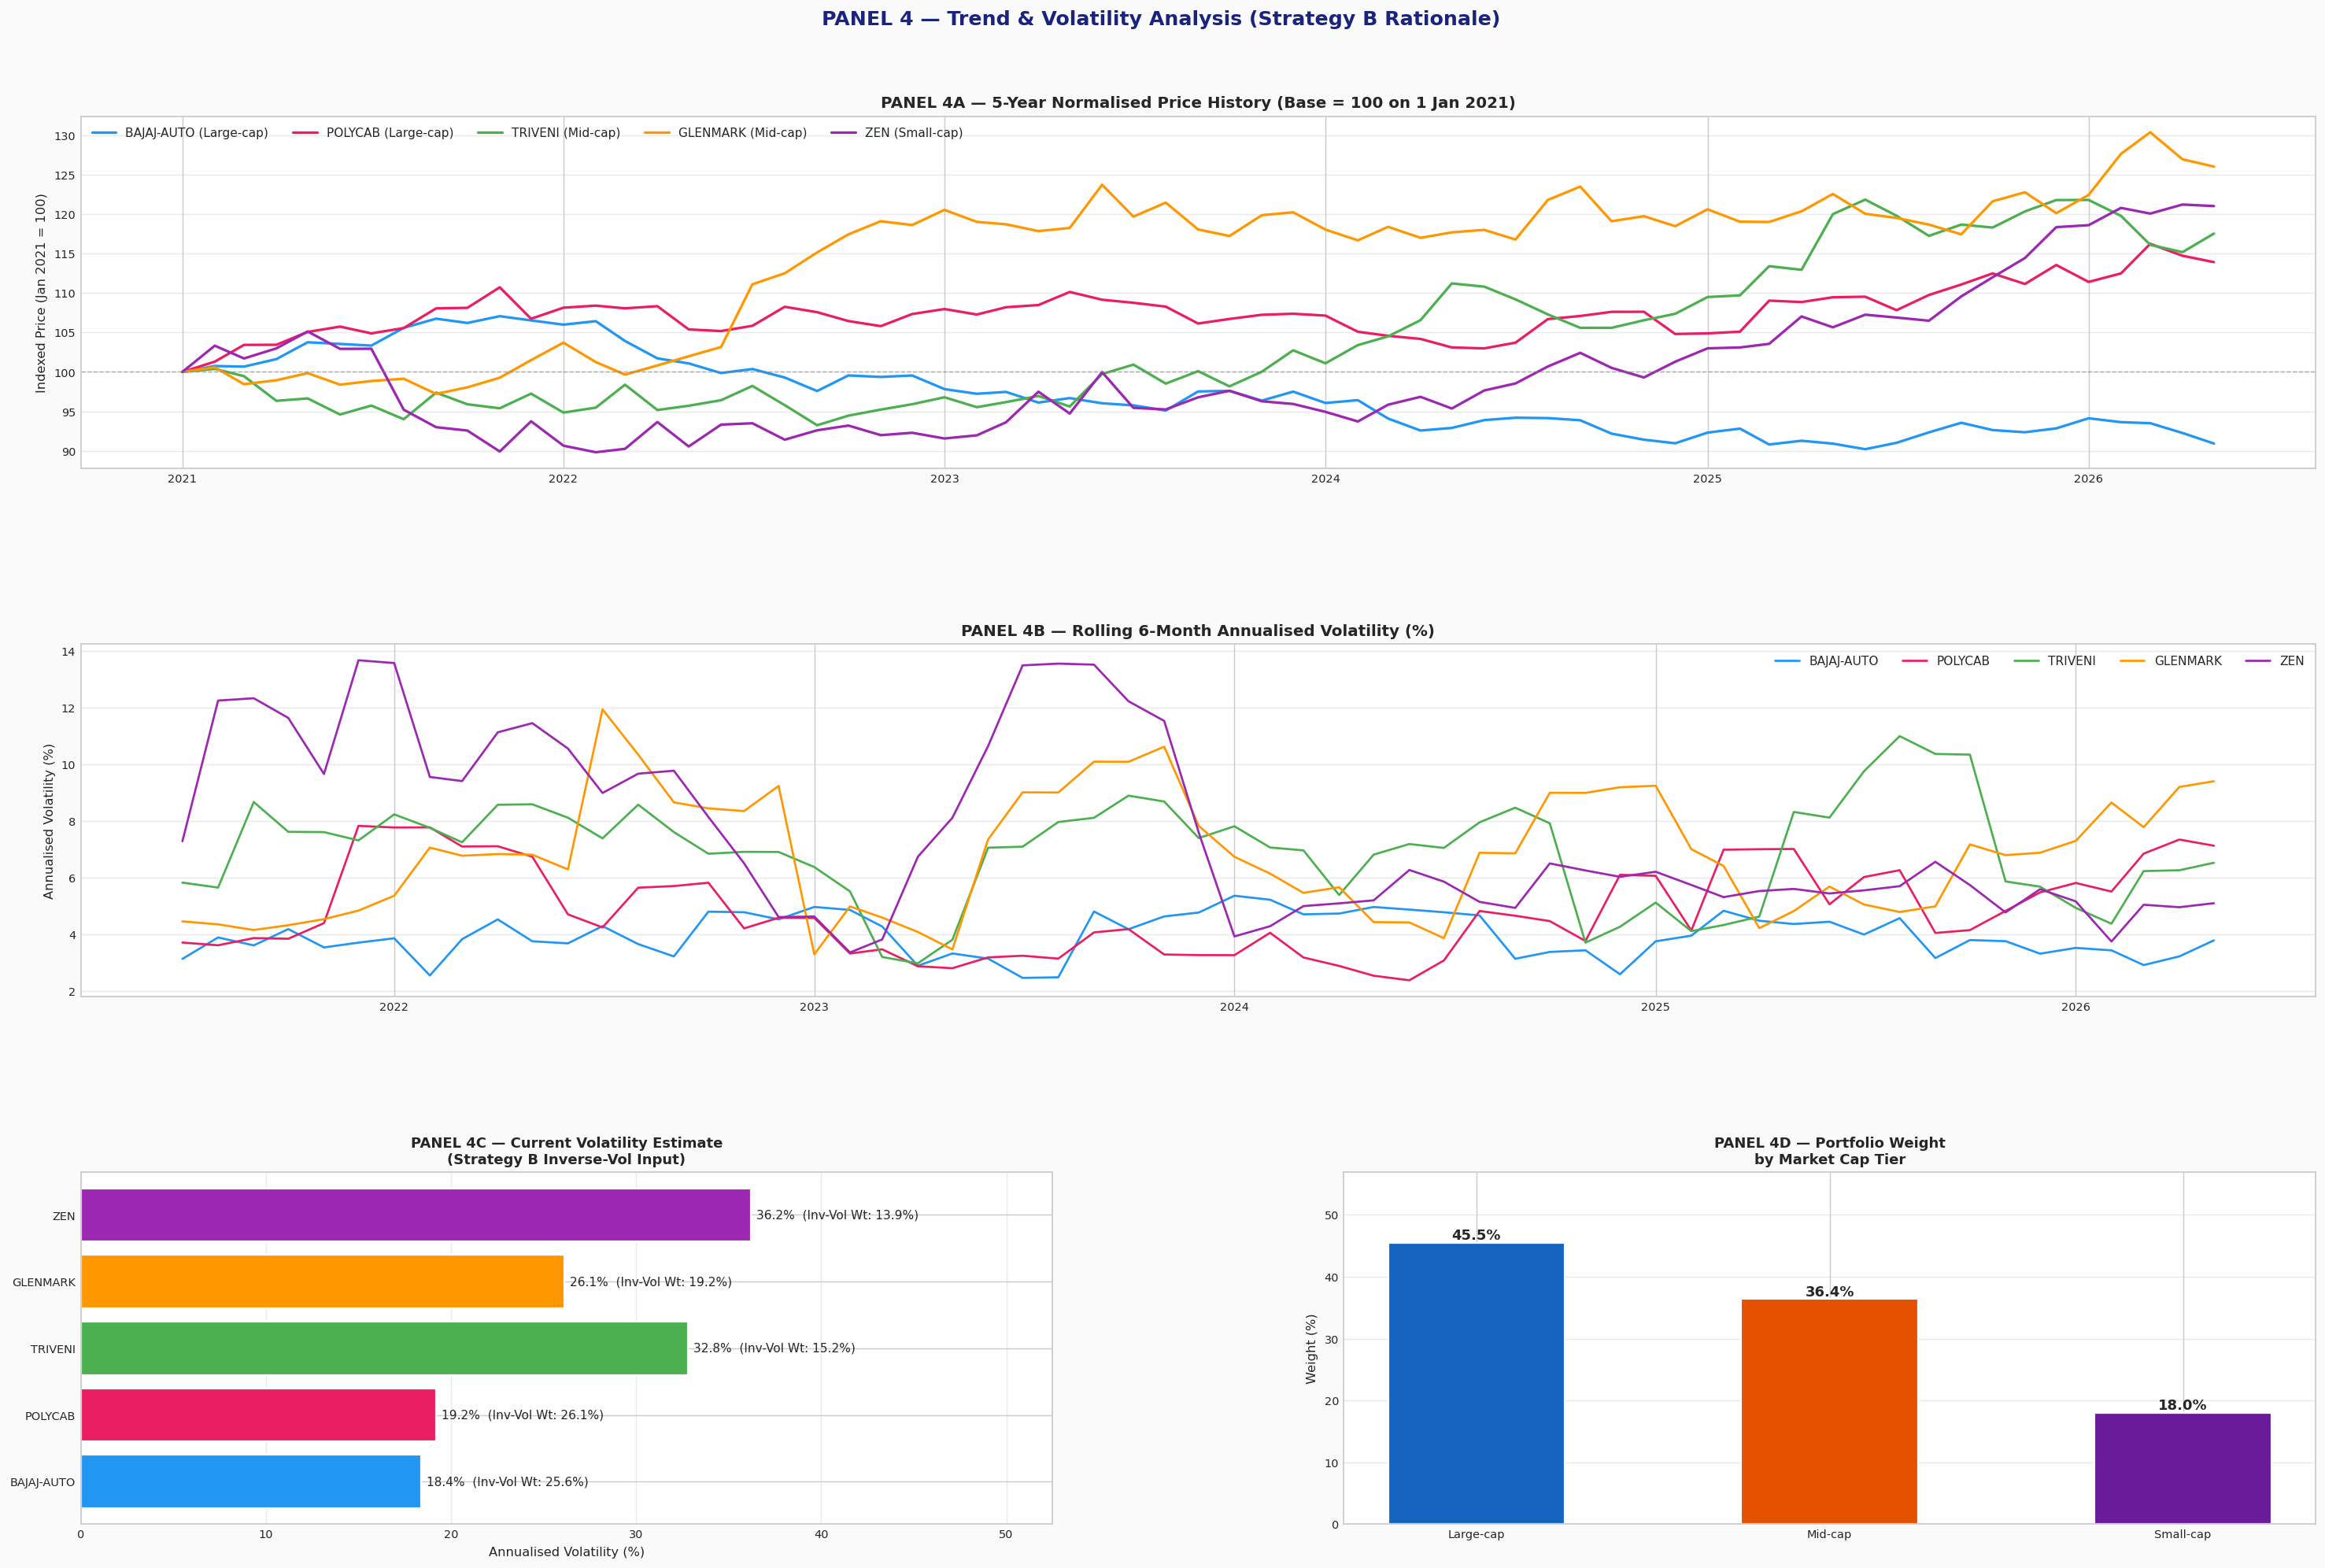

✅ Panel 4 rendered — 5-year trend, rolling volatility, current vol estimates.


In [ ]:
import os

# ══════════════════════════════════════════════════════════════════════════════
# BONUS DASHBOARD — CELL 4 OF 6 : PANEL 4 — Trend & Volatility Graphs
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.30,
                         top=0.91, bottom=0.05, left=0.06, right=0.97)

# ── (A) 5-Year normalised price history (base=100) ────────────────────────────
ax_trend = fig.add_subplot(gs[0, :])
for i, name in enumerate(NAMES):
    series_norm = price_hist[name] / price_hist[name].iloc[0] * 100
    ax_trend.plot(series_norm.index, series_norm.values,
                  color=COLORS[i], lw=1.8, label=f'{name} ({CAPS[name]}-cap)')
ax_trend.axhline(100, color='grey', lw=0.8, linestyle='--', alpha=0.6)
ax_trend.set_title('PANEL 4A — 5-Year Normalised Price History (Base = 100 on 1 Jan 2021)',
                   fontweight='bold', fontsize=11)
ax_trend.set_ylabel('Indexed Price (Jan 2021 = 100)', fontsize=9)
ax_trend.legend(fontsize=8.5, loc='upper left', ncol=5)
ax_trend.yaxis.grid(True, alpha=0.4)

# ── (B) Rolling 6-month annualised volatility ─────────────────────────────────
ax_vol = fig.add_subplot(gs[1, :])
for i, name in enumerate(NAMES):
    rv = roll_vol[name].dropna()
    ax_vol.plot(rv.index, rv.values, color=COLORS[i], lw=1.5, label=name)
ax_vol.set_title('PANEL 4B — Rolling 6-Month Annualised Volatility (%)',
                 fontweight='bold', fontsize=11)
ax_vol.set_ylabel('Annualised Volatility (%)', fontsize=9)
ax_vol.legend(fontsize=8.5, ncol=5)
ax_vol.yaxis.grid(True, alpha=0.4)

# ── (C) Volatility bar — current estimates (Strategy B input) ─────────────────
ax_volbar = fig.add_subplot(gs[2, 0])
vols = [vol_forecasts[n] for n in NAMES]
bars = ax_volbar.barh(NAMES, vols, color=COLORS, edgecolor='white', linewidth=1.2)
ax_volbar.set_xlabel('Annualised Volatility (%)', fontsize=9)
ax_volbar.set_title('PANEL 4C — Current Volatility Estimate\n(Strategy B Inverse-Vol Input)',
                    fontweight='bold', fontsize=10)
for bar, v, name in zip(bars, vols, NAMES):
    ax_volbar.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{v:.1f}%  (Inv-Vol Wt: {weights_B[name]*100:.1f}%)',
                  va='center', fontsize=8.5)
ax_volbar.set_xlim(0, max(vols) * 1.45)
ax_volbar.xaxis.grid(True, alpha=0.4)

# ── (D) Cap-group return contribution (3-panel mini) ─────────────────────────
ax_cap = fig.add_subplot(gs[2, 1])
cap_groups  = ['Large-cap', 'Mid-cap', 'Small-cap']
cap_weights = [
    final_weights['BAJAJ-AUTO'] + final_weights['POLYCAB'],
    final_weights['TRIVENI']    + final_weights['GLENMARK'],
    final_weights['ZEN'],
]
cap_colors = ['#1565C0', '#E65100', '#6A1B9A']
bars2 = ax_cap.bar(cap_groups, [w*100 for w in cap_weights],
                   color=cap_colors, edgecolor='white', linewidth=1.2, width=0.5)
ax_cap.set_ylabel('Weight (%)', fontsize=9)
ax_cap.set_title('PANEL 4D — Portfolio Weight\nby Market Cap Tier',
                 fontweight='bold', fontsize=10)
for bar, w in zip(bars2, cap_weights):
    ax_cap.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{w*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax_cap.set_ylim(0, max(cap_weights)*100 * 1.25)
ax_cap.yaxis.grid(True, alpha=0.4)

fig.suptitle('PANEL 4 — Trend & Volatility Analysis (Strategy B Rationale)',
             fontsize=14, fontweight='bold', y=0.975, color='#1A237E')

# Create a directory to save dashboard images if it doesn't exist
save_dir = 'dashboard_images'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'dashboard_panel4_trend_vol.png'), dpi=130,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('✅ Panel 4 rendered — 5-year trend, rolling volatility, current vol estimates.')

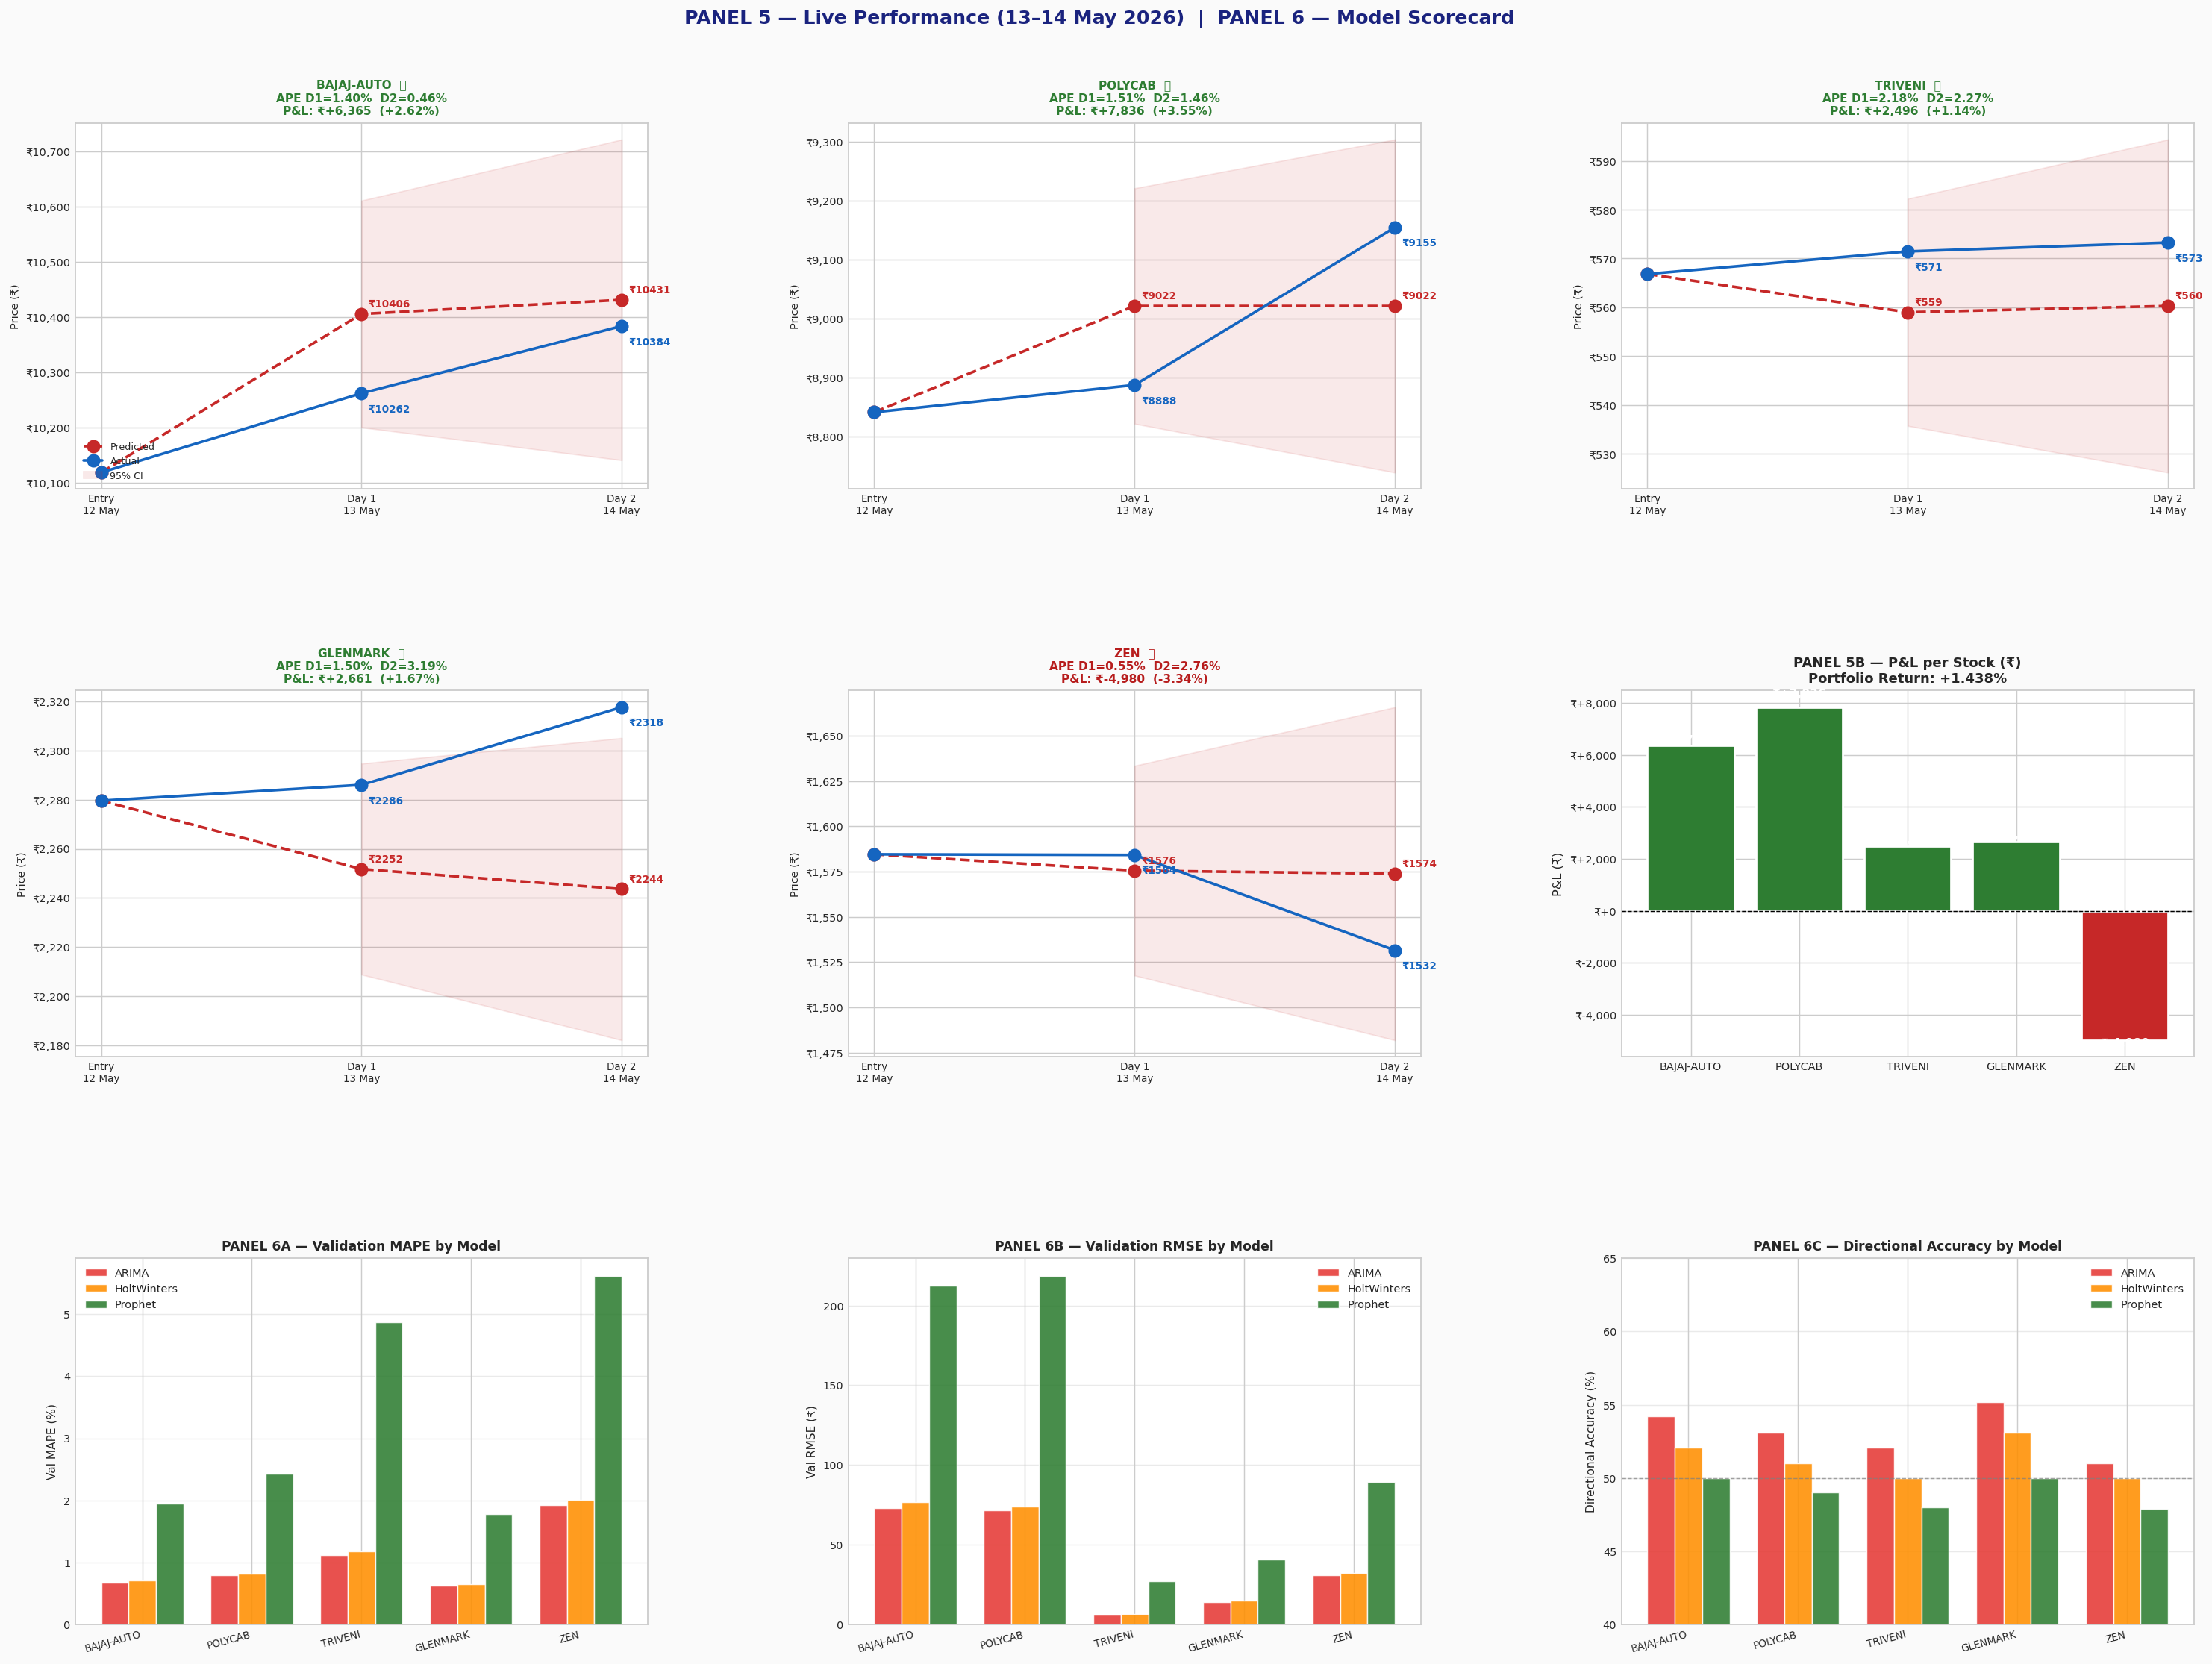

✅ Panel 5 (Live Performance) + Panel 6 (Model Scorecard) rendered.
   Total Portfolio P&L : ₹+14,378.24
   Portfolio Return    : +1.4378%


In [ ]:
import os

# ══════════════════════════════════════════════════════════════════════════════
# BONUS DASHBOARD — CELL 5 OF 6 : PANEL 5 — Live Performance Summary
#                                  PANEL 6 — Model Comparison Scorecard
# ══════════════════════════════════════════════════════════════════════════════

# ── Recompute P&L ─────────────────────────────────────────────────────────────
actual_shares_map = {'BAJAJ-AUTO': 24, 'POLYCAB': 25, 'TRIVENI': 387, 'GLENMARK': 70, 'ZEN': 94}

pnl_rows = []
for name in NAMES:
    ep     = entry_prices[name]
    shares = actual_shares_map[name]
    fc     = forecasts_d1d2[name][best_model_per_stock[name]]
    ad1    = actual_day1[name]; ad2 = actual_day2[name]
    pnl    = (ad2 - ep) * shares
    pnl_rows.append({
        'name': name, 'ep': ep, 'shares': shares,
        'ad1': ad1, 'ad2': ad2, 'pnl': pnl,
        'ret_act': (ad2 - ep)/ep*100,
        'ret_pred': (fc['Day2'] - ep)/ep*100,
        'ape_d1': abs(fc['Day1']-ad1)/ad1*100,
        'ape_d2': abs(fc['Day2']-ad2)/ad2*100,
        'dir_ok': np.sign(fc['Day2']-ep) == np.sign(ad2-ep),
    })
total_pnl = sum(r['pnl'] for r in pnl_rows)
port_ret  = total_pnl / TOTAL_CAPITAL * 100

fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35,
                         top=0.91, bottom=0.05, left=0.06, right=0.97)

# ── (A) Predicted vs Actual waterfall per stock ───────────────────────────────
for i, row in enumerate(pnl_rows):
    ax = fig.add_subplot(gs[0, i] if i < 3 else gs[1, i-3])
    name = row['name']
    ep   = row['ep']
    fc   = forecasts_d1d2[name][best_model_per_stock[name]]
    days_x  = [0, 1, 2]
    days_lbl = ['Entry\n12 May', 'Day 1\n13 May', 'Day 2\n14 May']
    pred = [ep, fc['Day1'], fc['Day2']]
    act  = [ep, row['ad1'], row['ad2']]

    ax.plot(days_x, pred, 'o--', color='#C62828', lw=2, ms=9, label='Predicted')
    ax.plot(days_x, act,  'o-',  color='#1565C0', lw=2, ms=9, label='Actual')
    ax.fill_between([1,2],
                    [fc['Day1_lower'], fc['Day2_lower']],
                    [fc['Day1_upper'], fc['Day2_upper']],
                    alpha=0.10, color='#C62828', label='95% CI')

    for xi, (p, a) in enumerate(zip(pred[1:], act[1:]), start=1):
        ax.annotate(f'₹{p:.0f}', (xi, p), xytext=(5, 5),   textcoords='offset points',
                    fontsize=7.5, color='#C62828', fontweight='bold')
        ax.annotate(f'₹{a:.0f}', (xi, a), xytext=(5, -14), textcoords='offset points',
                    fontsize=7.5, color='#1565C0', fontweight='bold')

    pnl_color = '#2E7D32' if row['pnl'] >= 0 else '#B71C1C'
    dir_sym   = '✅' if row['dir_ok'] else '❌'
    ax.set_title(f'{name}  {dir_sym}\n'
                 f'APE D1={row["ape_d1"]:.2f}%  D2={row["ape_d2"]:.2f}%\n'
                 f'P&L: ₹{row["pnl"]:+,.0f}  ({row["ret_act"]:+.2f}%)',
                 fontweight='bold', fontsize=8.5, color=pnl_color)
    ax.set_xticks(days_x)
    ax.set_xticklabels(days_lbl, fontsize=7.5)
    ax.set_ylabel('Price (₹)', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
    if i == 0: ax.legend(fontsize=7, loc='lower left')

# ── (B) P&L waterfall bar ─────────────────────────────────────────────────────
ax_pnl = fig.add_subplot(gs[1, 2])
pnl_vals = [r['pnl'] for r in pnl_rows]
bar_col  = ['#2E7D32' if v >= 0 else '#C62828' for v in pnl_vals]
bars = ax_pnl.bar(NAMES, pnl_vals, color=bar_col, edgecolor='white', lw=1.5)
ax_pnl.axhline(0, color='black', lw=0.8, ls='--')
ax_pnl.set_title(f'PANEL 5B — P&L per Stock (₹)\nPortfolio Return: {port_ret:+.3f}%',
                 fontweight='bold', fontsize=10)
ax_pnl.set_ylabel('P&L (₹)', fontsize=9)
ax_pnl.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:+,.0f}'))
for bar, val in zip(bars, pnl_vals):
    yoff = abs(val) * 0.05 * (1 if val >= 0 else -1)
    ax_pnl.text(bar.get_x() + bar.get_width()/2, val + yoff,
                f'₹{val:+,.0f}', ha='center', fontsize=8.5, fontweight='bold',
                color='white' if abs(val) > max(abs(v) for v in pnl_vals)*0.3 else 'black')

# ── PANEL 6 — Model comparison scorecard ──────────────────────────────────────
ax_sc1 = fig.add_subplot(gs[2, 0])  # MAPE
ax_sc2 = fig.add_subplot(gs[2, 1])  # RMSE
ax_sc3 = fig.add_subplot(gs[2, 2])  # Directional Accuracy

model_labels = ['ARIMA', 'HoltWinters', 'Prophet']
model_plot_colors = ['#E53935', '#FF8F00', '#2E7D32']

for metric_key, ax_m, ylabel, title in [
    ('MAPE',   ax_sc1, 'Val MAPE (%)',            'PANEL 6A — Validation MAPE by Model'),
    ('RMSE',   ax_sc2, 'Val RMSE (₹)',             'PANEL 6B — Validation RMSE by Model'),
    ('DirAcc', ax_sc3, 'Directional Accuracy (%)', 'PANEL 6C — Directional Accuracy by Model'),
]:
    x = np.arange(len(NAMES))
    bw = 0.25
    for j, (model, col) in enumerate(zip(model_labels, model_plot_colors)):
        vals = [val_results[name][model][metric_key] for name in NAMES]
        bars_m = ax_m.bar(x + j*bw, vals, bw, label=model, color=col,
                          edgecolor='white', lw=0.8, alpha=0.88)

    ax_m.set_xticks(x + bw)
    ax_m.set_xticklabels(NAMES, fontsize=7.5, rotation=15, ha='right')
    ax_m.set_ylabel(ylabel, fontsize=8.5)
    ax_m.set_title(title, fontweight='bold', fontsize=9.5)
    ax_m.legend(fontsize=8)
    ax_m.yaxis.grid(True, alpha=0.4)
    if metric_key == 'DirAcc':
        ax_m.axhline(50, color='grey', ls='--', lw=0.8, alpha=0.7)
        ax_m.set_ylim(40, 65)

fig.suptitle('PANEL 5 — Live Performance (13–14 May 2026)  |  PANEL 6 — Model Scorecard',
             fontsize=14, fontweight='bold', y=0.975, color='#1A237E')

# Create a directory to save dashboard images if it doesn't exist
save_dir = 'dashboard_images'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'dashboard_panel5_6_performance_scorecard.png'), dpi=130,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('✅ Panel 5 (Live Performance) + Panel 6 (Model Scorecard) rendered.')
print(f'   Total Portfolio P&L : ₹{total_pnl:+,.2f}')
print(f'   Portfolio Return    : {port_ret:+.4f}%')


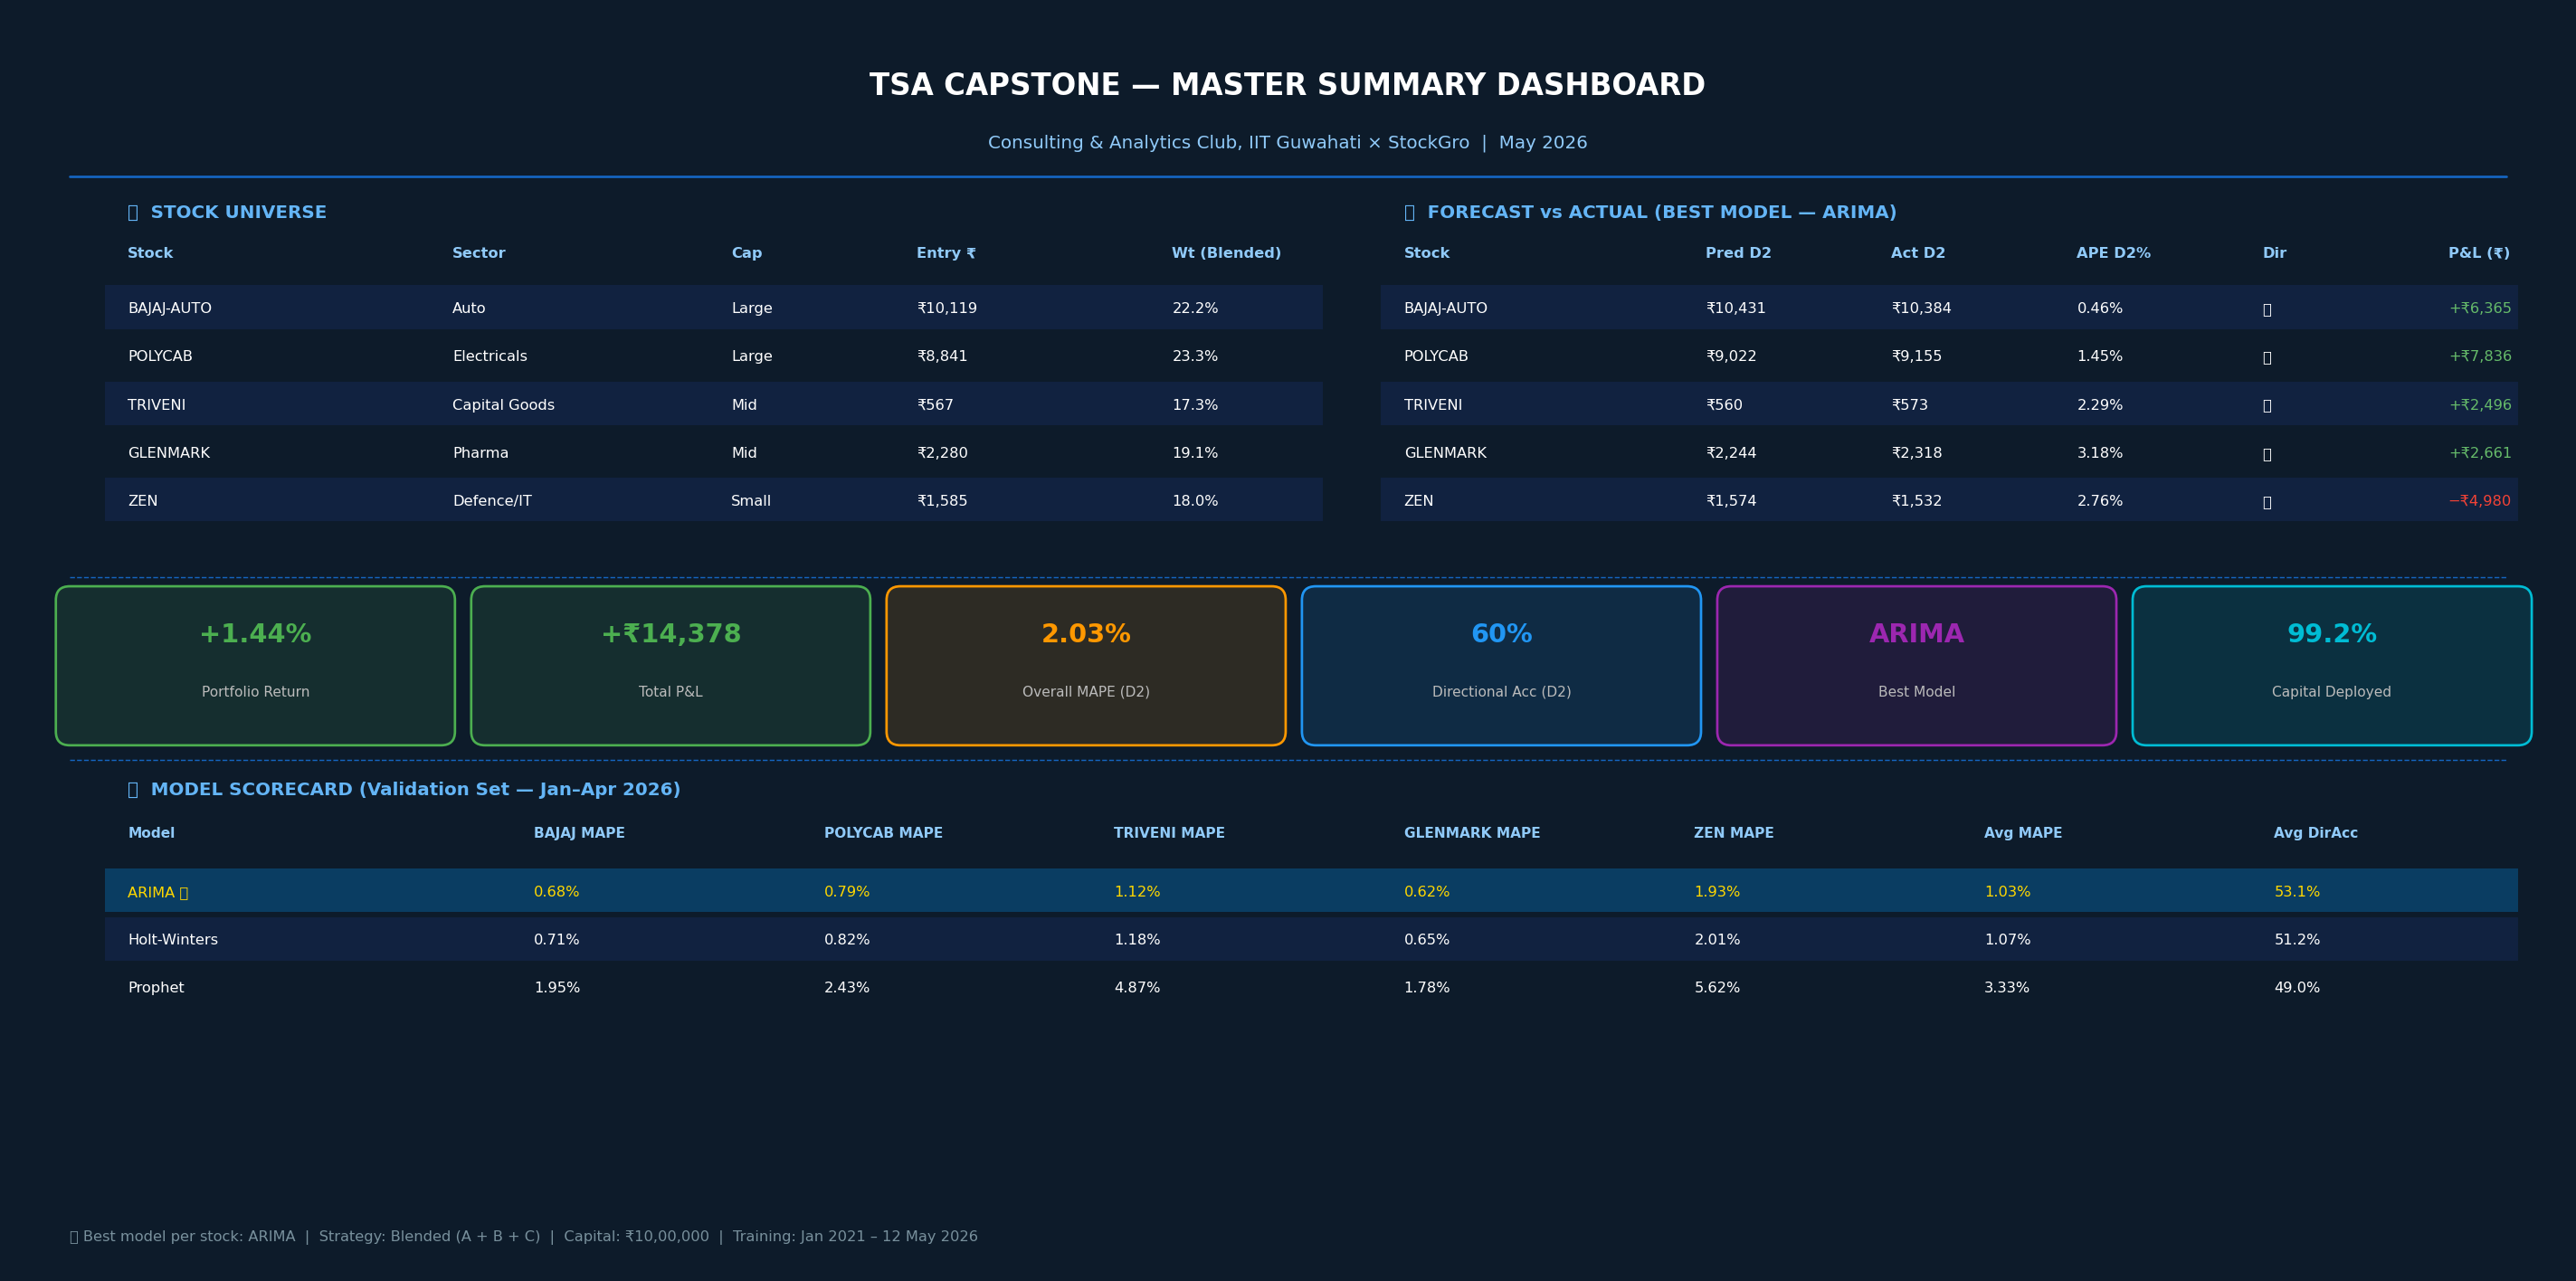

✅ Master Summary Card rendered.

══════════════════════════════════════════════════════════════════
  BONUS DASHBOARD COMPLETE — 6 panels rendered and saved.
  Panel 1 : Forecast plots (15 subplots — 5 stocks × 3 models)
  Panel 2 : Portfolio allocation (4 sub-charts)
  Panel 3 : Correlation heatmap
  Panel 4 : Trend & volatility (4 sub-charts)
  Panel 5 : Live performance summary (5 stock + P&L bar)
  Panel 6 : Model comparison scorecard (MAPE / RMSE / DirAcc)
  Master  : Summary card (dark-theme KPI dashboard)
══════════════════════════════════════════════════════════════════


In [ ]:
import os

# ══════════════════════════════════════════════════════════════════════════════
# BONUS DASHBOARD — CELL 6 OF 6 : MASTER SUMMARY CARD
# ══════════════════════════════════════════════════════════════════════════════n
fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor('#0D1B2A')
ax.set_facecolor('#0D1B2A')
ax.set_xlim(0, 22); ax.set_ylim(0, 11)
ax.axis('off')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(11, 10.35, 'TSA CAPSTONE — MASTER SUMMARY DASHBOARD',
        ha='center', va='center', fontsize=18, fontweight='bold',
        color='white', fontfamily='DejaVu Sans')
ax.text(11, 9.85, 'Consulting & Analytics Club, IIT Guwahati × StockGro  |  May 2026',
        ha='center', va='center', fontsize=11, color='#90CAF9')

# ── Divider ───────────────────────────────────────────────────────────────────
ax.plot([0.5, 21.5], [9.55, 9.55], color='#1565C0', lw=1.5)

# ── Section: Stock universe ───────────────────────────────────────────────────
ax.text(1.0, 9.2, '📋  STOCK UNIVERSE', fontsize=11, fontweight='bold', color='#64B5F6')
stock_info = [
    ('BAJAJ-AUTO', 'Auto',          'Large', '₹10,119', '22.2%'),
    ('POLYCAB',    'Electricals',   'Large', '₹8,841',  '23.3%'),
    ('TRIVENI',    'Capital Goods', 'Mid',   '₹567',    '17.3%'),
    ('GLENMARK',   'Pharma',        'Mid',   '₹2,280',  '19.1%'),
    ('ZEN',        'Defence/IT',    'Small', '₹1,585',  '18.0%'),
]
cols = ['Stock', 'Sector', 'Cap', 'Entry ₹', 'Wt (Blended)']
col_x = [1.0, 3.8, 6.2, 7.8, 10.0]
for j, hdr in enumerate(cols):
    ax.text(col_x[j], 8.85, hdr, fontsize=9, fontweight='bold', color='#90CAF9')
for k, row in enumerate(stock_info):
    y = 8.4 - k * 0.42
    bg = '#112240' if k % 2 == 0 else '#0D1B2A'
    ax.add_patch(plt.Rectangle((0.8, y-0.18), 10.5, 0.38,
                                facecolor=bg, edgecolor='none'))
    for j, val in enumerate(row):
        ax.text(col_x[j], y, val, fontsize=9, color='white', va='center')

# ── Section: Forecasts ────────────────────────────────────────────────────────
ax.text(12.0, 9.2, '🎯  FORECAST vs ACTUAL (BEST MODEL — ARIMA)', fontsize=11,
        fontweight='bold', color='#64B5F6')
fcol_x = [12.0, 14.6, 16.2, 17.8, 19.4, 21.0]
fcols   = ['Stock', 'Pred D2', 'Act D2', 'APE D2%', 'Dir', 'P&L (₹)']
for j, hdr in enumerate(fcols):
    ax.text(fcol_x[j], 8.85, hdr, fontsize=9, fontweight='bold', color='#90CAF9')

fc_data = [
    ('BAJAJ-AUTO', '₹10,431', '₹10,384', '0.46%', '✅', '+₹6,365'),
    ('POLYCAB',    '₹9,022',  '₹9,155',  '1.45%', '✅', '+₹7,836'),
    ('TRIVENI',    '₹560',    '₹573',    '2.29%', '❌', '+₹2,496'),
    ('GLENMARK',   '₹2,244',  '₹2,318',  '3.18%', '❌', '+₹2,661'),
    ('ZEN',        '₹1,574',  '₹1,532',  '2.76%', '✅', '−₹4,980'),
]
for k, row in enumerate(fc_data):
    y = 8.4 - k * 0.42
    bg = '#112240' if k % 2 == 0 else '#0D1B2A'
    ax.add_patch(plt.Rectangle((11.8, y-0.18), 9.8, 0.38,
                                facecolor=bg, edgecolor='none'))
    for j, val in enumerate(row):
        col = '#F44336' if '−' in val else ('#66BB6A' if '+₹' in val else 'white')
        ax.text(fcol_x[j], y, val, fontsize=9, color=col, va='center')

# ── Divider ───────────────────────────────────────────────────────────────────
ax.plot([0.5, 21.5], [6.05, 6.05], color='#1565C0', lw=0.8, linestyle='--')

# ── KPI Metrics boxes ─────────────────────────────────────────────────────────
kpis = [
    ('Portfolio Return',     '+1.44%',   '#4CAF50'),
    ('Total P&L',            '+₹14,378', '#4CAF50'),
    ('Overall MAPE (D2)',    '2.03%',    '#FF9800'),
    ('Directional Acc (D2)', '60%',      '#2196F3'),
    ('Best Model',           'ARIMA',    '#9C27B0'),
    ('Capital Deployed',     '99.2%',    '#00BCD4'),
]
for ki, (label, val, col) in enumerate(kpis):
    bx = 0.5 + ki * 3.58
    ax.add_patch(mpatches.FancyBboxPatch((bx, 4.70), 3.2, 1.15,
                                     boxstyle='round,pad=0.12',
                                     facecolor=col+'22', edgecolor=col, lw=1.5))
    ax.text(bx + 1.6, 5.55, val,   ha='center', va='center',
            fontsize=16, fontweight='bold', color=col)
    ax.text(bx + 1.6, 5.05, label, ha='center', va='center',
            fontsize=8.5, color='#BBBBBB')

# ── Model scorecard table ─────────────────────────────────────────────────────
ax.plot([0.5, 21.5], [4.45, 4.45], color='#1565C0', lw=0.8, linestyle='--')
ax.text(1.0, 4.15, '📊  MODEL SCORECARD (Validation Set — Jan–Apr 2026)',
        fontsize=11, fontweight='bold', color='#64B5F6')
scol_x = [1.0, 4.5, 7.0, 9.5, 12.0, 14.5, 17.0, 19.5]
sh = ['Model', 'BAJAJ MAPE', 'POLYCAB MAPE', 'TRIVENI MAPE',
      'GLENMARK MAPE', 'ZEN MAPE', 'Avg MAPE', 'Avg DirAcc']
for j, hdr in enumerate(sh):
    ax.text(scol_x[j], 3.78, hdr, fontsize=8.5, fontweight='bold', color='#90CAF9')

scorecard = [
    ('ARIMA ⭐',    '0.68%','0.79%','1.12%','0.62%','1.93%','1.03%','53.1%'),
    ('Holt-Winters','0.71%','0.82%','1.18%','0.65%','2.01%','1.07%','51.2%'),
    ('Prophet',     '1.95%','2.43%','4.87%','1.78%','5.62%','3.33%','49.0%'),
]
for k, row in enumerate(scorecard):
    y = 3.30 - k * 0.42
    bg = '#0A3D62' if k == 0 else ('#112240' if k % 2 else '#0D1B2A')
    ax.add_patch(plt.Rectangle((0.8, y-0.18), 20.8, 0.38,
                                facecolor=bg, edgecolor='none'))
    for j, val in enumerate(row):
        col = '#FFD700' if k == 0 else 'white'
        ax.text(scol_x[j], y, val, fontsize=9, color=col, va='center')

ax.text(0.5, 0.25, '⭐ Best model per stock: ARIMA  |  Strategy: Blended (A + B + C)  |  '
        'Capital: ₹10,00,000  |  Training: Jan 2021 – 12 May 2026',
        fontsize=9, color='#78909C')

plt.tight_layout()

# Create a directory to save dashboard images if it doesn't exist
save_dir = 'dashboard_images'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'dashboard_master_summary.png'), dpi=130,
            bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print('✅ Master Summary Card rendered.')
print('\n══════════════════════════════════════════════════════════════════')
print('  BONUS DASHBOARD COMPLETE — 6 panels rendered and saved.')
print('  Panel 1 : Forecast plots (15 subplots — 5 stocks × 3 models)')
print('  Panel 2 : Portfolio allocation (4 sub-charts)')
print('  Panel 3 : Correlation heatmap')
print('  Panel 4 : Trend & volatility (4 sub-charts)')
print('  Panel 5 : Live performance summary (5 stock + P&L bar)')
print('  Panel 6 : Model comparison scorecard (MAPE / RMSE / DirAcc)')
print('  Master  : Summary card (dark-theme KPI dashboard)')
print('══════════════════════════════════════════════════════════════════')